In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as stats
df = pd.read_csv(r"../../data/winemag-data-130k-v2.csv")


,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


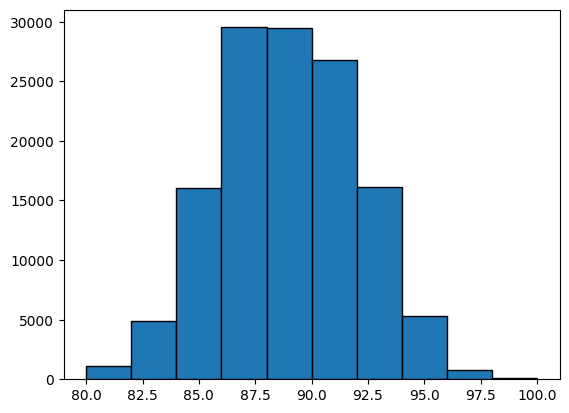

In [2]:
plt.hist(df['points'],edgecolor="black")


###Z-TEST

In [3]:
points=df['points']
mu=points.mean()
sigma=points.std()


mean= 88.44713820775404 std= 3.039730202916003


In [4]:
z_critical = 1.96 # alpha level of 0.05 and two-tailed test
x_bar = 90.2
N = 10
SE=sigma/np.sqrt(N)
z_stat=(x_bar-mu)/SE


1.8235288387320392


In [5]:
z_critical = 1.96 # alpha level of 0.05 and two-tailed test
x_bar = 90.2
N = 30
SE=sigma/np.sqrt(N)
z_stat=(x_bar-mu)/SE


3.1584445977509654


## T-TEST

In [6]:
x=np.random.normal(loc=9.2,scale=1.5,size=30).round(1)


array([ 9.5,  8.1,  6.3,  9.9,  8.4,  8.8,  7.1,  8.5,  8.1,  8.5,  9.5,
        9.6, 12.1, 10.5,  8.7, 10.7,  9.5,  8.8, 10.6,  8.8,  7. , 10.7,
       12.2,  8.9,  8.2,  9.6,  7.3,  9.2, 12.1,  8.5])

In [9]:
x = [8.8, 6.6, 9.5, 11.2, 10.2, 7.4, 8.0, 9.6, 9.9, 9.0,
     7.6, 7.4, 10.4, 11.1, 8.5, 10.0, 11.6, 10.7, 10.3, 7.0]
mu = 10
t_critical = 2.093
x_bar=np.array(x).mean()
s=np.array(x).std(ddof=1)
N=len(x)
SE=s/np.sqrt(N)
t_stat=(x_bar-mu)/SE


-2.2491611580763977


In [8]:
t,p=stats.ttest_1samp(x,mu)


t: -2.2491611580763973 p: 0.03655562279112415


In [11]:
## margin of error
err=t_critical*SE
x_low=x_bar-err
x_high=x_bar+err


x_bar=9.24,%95 CI=[8.53,9.95]


CI using scipy (8.532759313560822, 9.947240686439175)


In [20]:
# sample up wind
x1 = [10.8, 10.0, 8.2, 9.9, 11.6, 10.1, 11.3, 10.3, 10.7, 9.7, 
      7.8, 9.6, 9.7, 11.6, 10.3, 9.8, 12.3, 11.0, 10.4, 10.4]

# sample down wind
x2 = [7.8, 7.5, 9.5, 11.7, 8.1, 8.8, 8.8, 7.7, 9.7, 7.0, 
      9.0, 9.7, 11.3, 8.7, 8.8, 10.9, 10.3, 9.6, 8.4, 6.6,
      7.2, 7.6, 11.5, 6.6, 8.6, 10.5, 8.4, 8.5, 10.2, 9.2]

# equal sample size and assume equal population variance
t_critical = 1.677
N1=len(x1)
N2=len(x2)
x1_bar=np.array(x1).mean()
x2_bar=np.array(x2).mean()
s1=np.array(x1).std(ddof=1)
s2=np.array(x2).std(ddof=1)
d1=N1-1
d2=N2-1
d=d1+d2

sp=np.sqrt((d1*s1**2 + d2*s2**2)/d)
se=sp*np.sqrt(1/N1 + 1/N2)
t=(x2_bar-x1_bar)/se


t_stat: -3.5981947686898033


In [22]:
t,p=stats.ttest_ind(x2,x1,equal_var=True)


t: -3.5981947686898033 p: 0.0007560337478801464


In [28]:
print("CI:",stats.t.interval(0.95,df,loc=int(x2_bar)-int(x1_bar),scale=se))



TypeError: '>' not supported between instances of 'str' and 'int'

In [23]:
# sample before conversion to nat. gas
x1 = np.array([10.8, 6.4, 8.3, 7.6, 11.4, 9.9, 10.6, 8.7, 8.1, 10.9,
      11.0, 11.8, 7.3, 9.6, 9.3, 9.9, 9.0, 9.5, 10.6, 10.3,
      8.8, 12.3, 8.9, 10.5, 11.6, 7.6, 8.9, 10.4, 10.2, 8.8])
# sample after conversion to nat. gas
x2 = np.array([10.1, 6.9, 8.6, 8.8, 12.1, 11.3, 12.4, 9.3, 9.3, 10.8,
      12.4, 11.5, 7.4, 10.0, 11.1, 10.6, 9.4, 9.5, 10.0, 10.0,
      9.7, 13.5, 9.6, 11.6, 11.7, 7.9, 8.6, 10.8, 9.5, 9.6])
N = len(x2)
xbar_diff = np.mean(x2) - np.mean(x1) # could also do np.mean(x2 - x1))
sdiff = np.std(x2-x1,ddof=1)
t = xbar_diff / (sdiff/np.sqrt(N))
print("t = ", t)

t, p = stats.ttest_rel(x2, x1) # using scipy
print("t = ", t, ", p = ", p/2) # divide by two because we are doing a one-tail test

d = xbar_diff / sdiff


t =  3.9054390813265063
t =  3.905439081326491 , p =  0.0002584344912342189
d =  0.7130323606015934


In [24]:
# sample before conversion to nat. gas
x1 = np.array([10.8, 6.4, 8.3, 7.6, 11.4, 9.9, 10.6, 8.7, 8.1, 10.9,
      11.0, 11.8, 7.3, 9.6, 9.3, 9.9, 9.0, 9.5, 10.6, 10.3,
      8.8, 12.3, 8.9, 10.5, 11.6, 7.6, 8.9, 10.4, 10.2, 8.8])
# sample after conversion to nat. gas
x2 = np.array([10.1, 6.9, 8.6, 8.8, 12.1, 11.3, 12.4, 9.3, 9.3, 10.8,
      12.4, 11.5, 7.4, 10.0, 11.1, 10.6, 9.4, 9.5, 10.0, 10.0,
      9.7, 13.5, 9.6, 11.6, 11.7, 7.9, 8.6, 10.8, 9.5, 9.6])
N2=len(x2)
N1=len(x1)
xbar_diff=np.mean(x2-x1)
s1=np.array(x1).std(ddof=1)
s2=np.array(x2).std(ddof=1)
sdiff=np.sqrt(s1**2 /N1 + s2**2 /N2)
t=xbar_diff/(sdiff*np.sqrt(N2))


0.2378133786789196
